<a href="https://colab.research.google.com/github/Nour-Tamimi/BinXtraining/blob/main/Week8/Day3/Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_006e9dd67e4d0f4db916dba6e5d805d9"

In [3]:
!pip install -q kaggle --upgrade
!kaggle datasets download -d vencerlanz09/plastic-paper-garbage-bag-synthetic-images
!unzip -q plastic-paper-garbage-bag-synthetic-images.zip -d data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.7 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/plastic-paper-garbage-bag-synthetic-images
License(s): CC-BY-SA-4.0
100% 451M/451M [00:04<00:00, 107MB/s]



In [4]:
import os
for folder in os.listdir("data"):
    print(folder)

ImageClassesCombinedWithCOCOAnnotations
Bag Classes


In [6]:
import os
for folder in os.listdir("data/Bag Classes/Bag Classes"):
    print(folder)

Plastic Bag Images
Garbage Bag Images
Paper Bag Images


In [7]:
import os

# Build the full path to one class folder
plastic_folder = "data/Bag Classes/Bag Classes/Plastic Bag Images"

# List the filenames inside it
filenames = os.listdir(plastic_folder)

# How many images are in this class, and what's the first filename?
print("number of images:", len(filenames))
print("first filename:", filenames[0])

number of images: 5000
first filename: 00001424.jpg


raw shape: (300, 300, 3)
pixel value range: 0 to 255


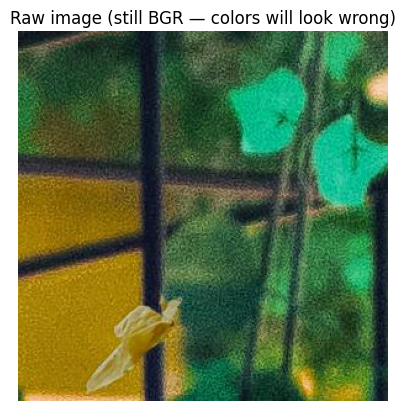

In [8]:
import cv2                       # OpenCV — the library that reads and edits images
import matplotlib.pyplot as plt  # lets us display images in Colab

# Build the full path to that first image
image_path = "data/Bag Classes/Bag Classes/Plastic Bag Images/00001424.jpg"

# Step 1: Read the image from disk.
# cv2.imread loads it as a NumPy array of pixel numbers (height x width x 3 colors).
# IMPORTANT: OpenCV loads colors in BGR order (Blue, Green, Red) — not RGB.
img = cv2.imread(image_path)

print("raw shape:", img.shape)   # (height, width, 3) — the 3 is the color channels
print("pixel value range:", img.min(), "to", img.max())   # should be 0 to 255

# Show it AS-IS (before fixing colors) so you can see the BGR problem for yourself
plt.imshow(img)
plt.title("Raw image (still BGR — colors will look wrong)")
plt.axis("off")
plt.show()

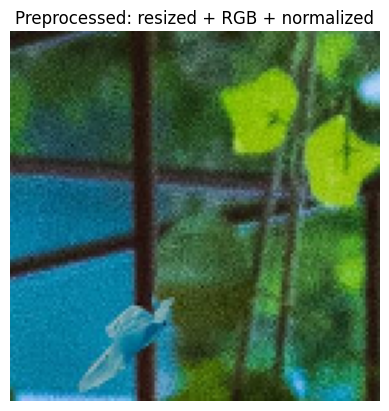

In [10]:
#Resize to a fixed size every image will share (128x128).
img_resized = cv2.resize(img, (128,128))

# Convert BGR to RGB so colors are correct.
image_rgb =cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

#Scale pixel values from 0-255 down to 0-1.
img_normalized = image_rgb /255.0

 #Show the final image
plt.imshow(img_normalized)
plt.title("Preprocessed: resized + RGB + normalized")
plt.axis("off")
plt.show()

In [13]:
#to apply for all images
def preprocess_image(path, size=(128,128)):
  img = cv2.imread(path)
  img = cv2.resize(img, size)
  img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  img = img /255.0

  return img

In [14]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20, zoom_range=0.15,
    horizontal_flip=True, brightness_range=[0.8, 1.2],
    rescale=1./255)

In [15]:
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array
img = cv2.imread(image_path)
img = cv2.resize(img, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# datagen expects a "batch" of images, even if it's just one.

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

aug_iter = datagen.flow(img_array, batch_size=1)


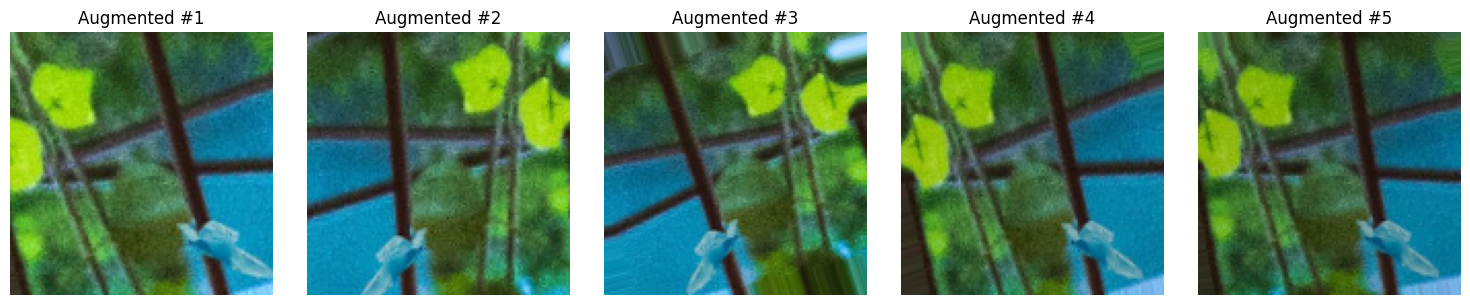

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    batch = next(aug_iter)      # generates one new randomized image
    axes[i].imshow(batch[0])    # batch[0] is that image, already 0-1 normalized
    axes[i].set_title(f"Augmented #{i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# MobileNetV2 was trained on 224x224 images — a different size than our 128x128!
img = cv2.imread(image_path)
img = cv2.resize(img, (224, 224))            # resize to what MobileNetV2 expects
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_array = np.expand_dims(img.astype(np.float32), axis=0)  # add batch dimension
processed = preprocess_input(img_array)

print("shape:", processed.shape)
print("pixel range:", processed.min(), "to", processed.max())


shape: (1, 224, 224, 3)
pixel range: -1.0 to 0.99215686
